In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [73]:
df = pd.read_csv('/content/titanic_toy.csv')

In [74]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [75]:
df.isnull().mean()*100

,0
Age,19.865320
Fare,5.050505
Family,0.000000
Survived,0.000000


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [77]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [78]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [79]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [80]:
X_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


In [81]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_minus1']=X_train['Age'].fillna(-1)

X_train['Fare_99']=X_train['Fare'].fillna(99)
X_train['Fare_minus1']=X_train['Fare'].fillna(-1)

In [82]:
X_train.sample(5)

,Age,Fare,Family,Age_99,Age_minus1,Fare_99,Fare_minus1
710,24.0,49.5042,0,24.0,24.0,49.5042,49.5042
577,39.0,55.9000,1,39.0,39.0,55.9000,55.9000
154,NaN,7.3125,0,99.0,-1.0,7.3125,7.3125
90,29.0,8.0500,0,29.0,29.0,8.0500,8.0500
25,38.0,31.3875,6,38.0,38.0,31.3875,31.3875


In [83]:

print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_99'].var())
print('Age Variance after mean imputation: ', X_train['Age_minus1'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_99'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  951.7275570187172
Age Variance after mean imputation:  318.0896202624484
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2536.0773428319685
Fare Variance after mean imputation:  2378.5676784883503


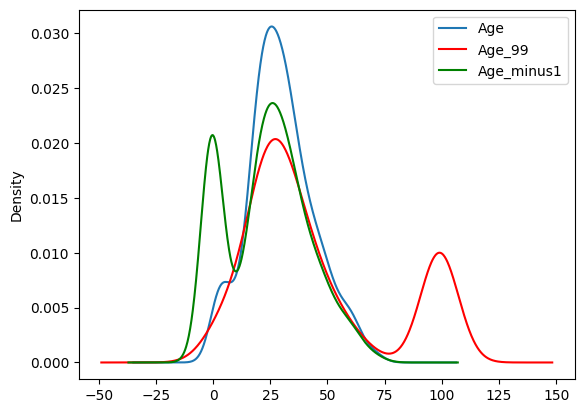

In [84]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax)

X_train['Age_99'].plot(kind='kde',ax=ax,color='red')

X_train['Age_minus1'].plot(kind='kde',ax=ax,color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')



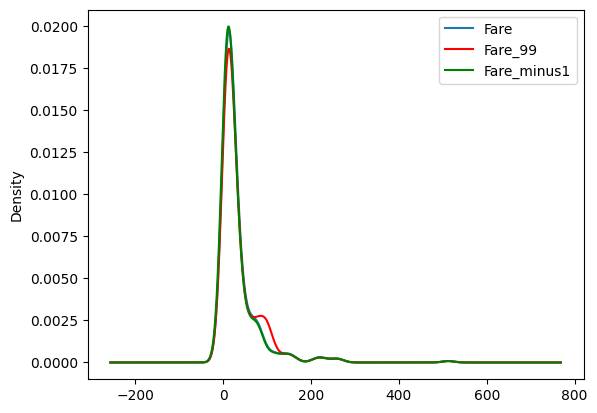

In [85]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax)

X_train['Fare_99'].plot(kind='kde',ax=ax,color='red')

X_train['Fare_minus1'].plot(kind='kde',ax=ax,color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')


In [86]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_99,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,73.268412,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,16.051452,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-100.878826,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,128.692715,114.394141
Fare_99,73.268412,2448.197914,16.051452,-100.878826,128.692715,2536.077343,2216.958409
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,2216.958409,2378.567678


In [87]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_99,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.095527,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.192723,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.064933,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.143284,0.131514
Fare_99,0.095527,1.000000,0.192723,-0.064933,0.143284,1.000000,0.902648
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.902648,1.000000


<Axes: >

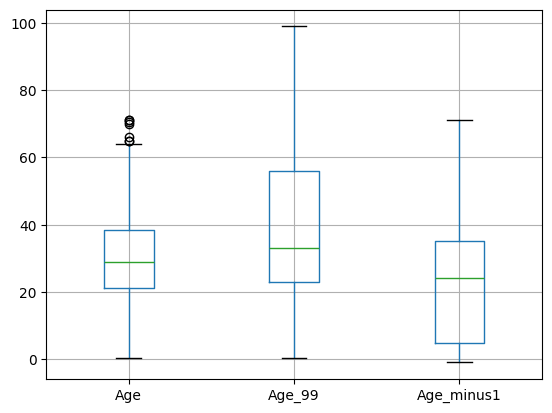

In [88]:
X_train[['Age','Age_99','Age_minus1']].boxplot()

<Axes: >

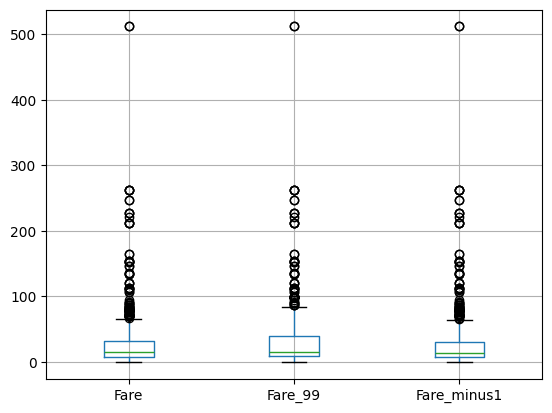

In [89]:
X_train[['Fare','Fare_99','Fare_minus1']].boxplot()


# Using Sklearn

In [90]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [91]:
X_train.head()

,Age,Fare,Family
30,40.0,27.7208,0
10,4.0,16.7000,2
873,47.0,9.0000,0
182,9.0,31.3875,6
876,20.0,9.8458,0


In [92]:
trf =ColumnTransformer([
    ('mean',SimpleImputer(strategy='constant',fill_value=99),[0]),
    ('median',SimpleImputer(strategy='constant',fill_value=999),[1])

],remainder='passthrough')

In [93]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [97]:
trf.named_transformers_['mean'].statistics_

array([99.])

In [98]:
trf.named_transformers_['median'].statistics_

array([999.])

In [100]:
X_train_trf

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])